In [ ]:
# install.packages("bigrquery")
library(bigrquery)
# bq_auth()

Please point your browser to the following url: 

JAB CHALAO HY TO DIKH JAYEGA


Enter authorization code: ME NAHI BTAONGA

In [ ]:
library(bigrquery)
# heroic-bliss-292505.staging.pre_post_analysis
sql_saad <- "SELECT
  CAST(Reporting_starts AS DATE) AS integration_date,
  -- Flag the pre/post window relative to May 25, 2026
  CASE
    WHEN CAST(Reporting_starts AS DATE) < '2026-05-25' THEN 'Pre-EMQ'
    ELSE 'Post-EMQ'
  END AS period,

  -- Core Aggregates
  SUM(Amount_spent__USD_) AS total_spend,
  SUM(Impressions) AS total_impressions,
  SUM(Clicks__all_) AS total_clicks,
  SUM(Subscriptions) AS total_subscriptions,

  -- Your 4 Required Target Metrics
  SAFE_DIVIDE(SUM(Clicks__all_), SUM(Impressions)) AS CTR,
  SAFE_DIVIDE(SUM(Subscriptions), SUM(Clicks__all_)) AS Conversion_Rate,
  SAFE_DIVIDE(SUM(Amount_spent__USD_), SUM(Subscriptions)) AS Cost_per_Subscribe
FROM `heroic-bliss-292505.staging.destify_campaign_manager_1feb26_24jun26`
-- Equal 30-day window balance around May 25th
WHERE CAST(Reporting_starts AS DATE) BETWEEN '2026-04-25' AND '2026-06-24'
GROUP BY all
-- ORDER BY integration_date ASC;
"
projectid = "heroic-bliss-292505"
# Run the query
project_query <- bq_project_query(projectid, sql_saad, use_legacy_sql = FALSE)
# Download result to dataframe
BQ_ <- bq_table_download(project_query)
str(BQ_)
summary(BQ_)
View(BQ_)

ERROR: Error in bq_project_query(projectid, sql_saad, use_legacy_sql = FALSE): could not find function "bq_project_query"


In [1]:
BQ_ = read.csv('Destify-Campaigns-1-Jan-2025-28-Jun-2026.csv')

In [5]:
# BQ_$timestamp = as.POSIXlt.character(BQ_$Reporting_starts)
# Rename columns to remove or replace the period with an underscore
colnames(BQ_) <- gsub("\\.", "_", colnames(BQ_))
BQ_$timestamp = as.POSIXlt.character(BQ_$Reporting_starts)
# Verify the column names are now valid for BigQuery
colnames(BQ_)
str(BQ_)
summary(BQ_)




'data.frame':	73984 obs. of  26 variables:
 $ Reporting_starts                      : chr  "2026-02-20" "2025-02-13" "2026-03-13" "2026-03-28" ...
 $ Reporting_ends                        : chr  "2026-02-20" "2025-02-13" "2026-03-13" "2026-03-28" ...
 $ Campaign_name                         : chr  "Destify Lead Forms Campaign" "Lightbulb - CBO - Cold Prospecting - 7DC1DV - Initiate Checkout" "Moonwater 1 - Prospecting - Testing - Subscribe - CBO - MAXC" "Moonwater 1 - Prospecting - Testing - Subscribe - CBO - MAXC" ...
 $ Campaign_delivery                     : chr  "inactive" "inactive" "active" "active" ...
 $ Results                               : int  51 NA 1 1 1 1 3 1 35 5 ...
 $ Result_indicator                      : chr  "actions:leadgen.other" "" "conversions:subscribe_website" "conversions:subscribe_website" ...
 $ Cost_per_results                      : num  6.64 NA 324.05 309.07 296.8 ...
 $ Ad_set_budget                         : chr  "25" "300" "1200" "1200" ...
 $ Ad_se

### Analysis of Destify Campaigns: Pre-EMQ vs Post-EMQ Performance

We are using the `Destify-Campaigns-1-Jan-2025-28-Jun-2026.csv` data to analyze campaign performance. The `BQ_` dataframe has been loaded from this CSV.

The core of our analysis is to compare campaign metrics before and after the 'EMQ' period, defined around May 25, 2026.

#### Pre-EMQ vs Post-EMQ Average Metrics and Percentage Differences

As calculated in the previous cells (`CgycMQeGee7G` and `e9b63ef8`), here's a summary of the average metrics and their percentage changes between the 'Pre-EMQ' and 'Post-EMQ' periods:

*   **Total Spend, Impressions, and Clicks** increased significantly.
*   **Total Subscriptions** increased, but at a comparatively lower rate.
*   **CTR** and **Conversion Rate** both saw a decrease.
*   **Cost per Subscribe** increased.

This data suggests that while ad spend increased post-EMQ, the efficiency of the campaigns (in terms of generating clicks, conversions, and cost-per-subscription) deteriorated.

#### Visualizing Trends with Spend and Other Metrics

The plots generated in cells `a1dd63a1` and `f64c8b93` effectively show the daily trends for `total_spend`, `total_impressions`, `total_clicks`, `total_subscriptions`, `CTR`, `Conversion_Rate`, and `Cost_per_Subscribe`. The use of `color = period` in these plots clearly distinguishes the 'Pre-EMQ' and 'Post-EMQ' phases, allowing for a visual comparison of how these metrics changed over time relative to the period. This fulfills the request to visualize spend alongside other metrics.

#### Limitations: Historical Benchmarking and GA4 Attribution

The action items related to **benchmarking against previous spend increases**, **benchmarking by absolute spend levels**, and **pulling historical attribution data from GA4** cannot be fully addressed with the current `BQ_` dataframe. The dataset covers a specific time range (April 25, 2026, to June 24, 2026) and does not include the necessary broader historical context or GA4-specific attribution metrics required for these analyses. To proceed with these, additional historical campaign data or access to GA4 would be needed.

In [ ]:
library(dplyr)

# Group by period and calculate the mean for each metric
summary_metrics <- BQ_ %>%
  group_by(period) %>%
  summarise(
    avg_total_spend = mean(total_spend, na.rm = TRUE),
    avg_total_impressions = mean(total_impressions, na.rm = TRUE),
    avg_total_clicks = mean(total_clicks, na.rm = TRUE),
    avg_total_subscriptions = mean(total_subscriptions, na.rm = TRUE),
    avg_CTR = mean(CTR, na.rm = TRUE),
    avg_Conversion_Rate = mean(Conversion_Rate, na.rm = TRUE),
    avg_Cost_per_Subscribe = mean(Cost_per_Subscribe, na.rm = TRUE)
  )

# Extract Pre-EMQ and Post-EMQ data
pre_emq <- summary_metrics %>%
  filter(period == "Pre-EMQ")

post_emq <- summary_metrics %>%
  filter(period == "Post-EMQ")

# Calculate differences (Post-EMQ - Pre-EMQ)
differences <- post_emq %>%
  ungroup() %>%
  select(-period) - pre_emq %>%
  ungroup() %>%
  select(-period)

# Rename columns for clarity
colnames(differences) <- paste0("diff_", colnames(differences))

print("Average metrics by period:")
print(summary_metrics)
print("\nDifferences (Post-EMQ - Pre-EMQ):")
print(differences)

[1] "Average metrics by period:"
# A tibble: 2 × 8
  period   avg_total_spend avg_total_impressions avg_total_clicks
  <chr>              <dbl>                 <dbl>            <dbl>
1 Post-EMQ           1442.                98193.            2620.
2 Pre-EMQ             959.                62846.            1694.
# ℹ 4 more variables: avg_total_subscriptions <dbl>, avg_CTR <dbl>,
#   avg_Conversion_Rate <dbl>, avg_Cost_per_Subscribe <dbl>
[1] "\nDifferences (Post-EMQ - Pre-EMQ):"
  diff_avg_total_spend diff_avg_total_impressions diff_avg_total_clicks
1             482.8888                    35347.2              925.8301
  diff_avg_total_subscriptions  diff_avg_CTR diff_avg_Conversion_Rate
1                          6.4 -0.0009898346             -0.001269228
  diff_avg_Cost_per_Subscribe
1                    6.647394


In [ ]:
library(dplyr)

# Ensure pre_emq is just the numeric values for calculation
pre_emq_values <- pre_emq %>%
  select(-period)

# Calculate percentage differences
percentage_differences <- (differences / pre_emq_values) * 100

# Rename columns for clarity
colnames(percentage_differences) <- paste0("pct_diff_", colnames(percentage_differences))

print("\nPercentage Differences (Post-EMQ vs Pre-EMQ):")
print(percentage_differences)

[1] "\nPercentage Differences (Post-EMQ vs Pre-EMQ):"
  pct_diff_diff_avg_total_spend pct_diff_diff_avg_total_impressions
1                      50.36506                            56.24421
  pct_diff_diff_avg_total_clicks pct_diff_diff_avg_total_subscriptions
1                       54.64489                              37.79528
  pct_diff_diff_avg_CTR pct_diff_diff_avg_Conversion_Rate
1             -3.596101                         -12.55016
  pct_diff_diff_avg_Cost_per_Subscribe
1                             10.67363


## Calculating Diminishing Returns of Ad Spend

To understand diminishing returns, we'll examine how `total_subscriptions` respond to changes in `total_spend`. We can use a regression model to quantify this relationship.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”



Call:
lm(formula = total_subscriptions ~ total_spend, data = BQ_)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.3036  -4.7695   0.0949   3.6946  16.6989 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 5.807797   3.044604   1.908   0.0614 .  
total_spend 0.011703   0.002402   4.873 8.89e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.129 on 58 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.2905,	Adjusted R-squared:  0.2782 
F-statistic: 23.74 on 1 and 58 DF,  p-value: 8.891e-06



Call:
lm(formula = total_subscriptions ~ total_spend + I(total_spend^2), 
    data = BQ_)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.6986  -4.3085   0.1025   3.7028  16.1854 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)  
(Intercept)      -8.450e+00  1.034e+01  -0.817   0.4172  
total_spend       3.921e-02  1.923e-02   2.039   0.0461 *
I(total_spend^2) -1.208e-05  8.381e-06  -1.442   0.1549  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.073 on 57 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.3154,	Adjusted R-squared:  0.2914 
F-statistic: 13.13 on 2 and 57 DF,  p-value: 2.04e-05


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


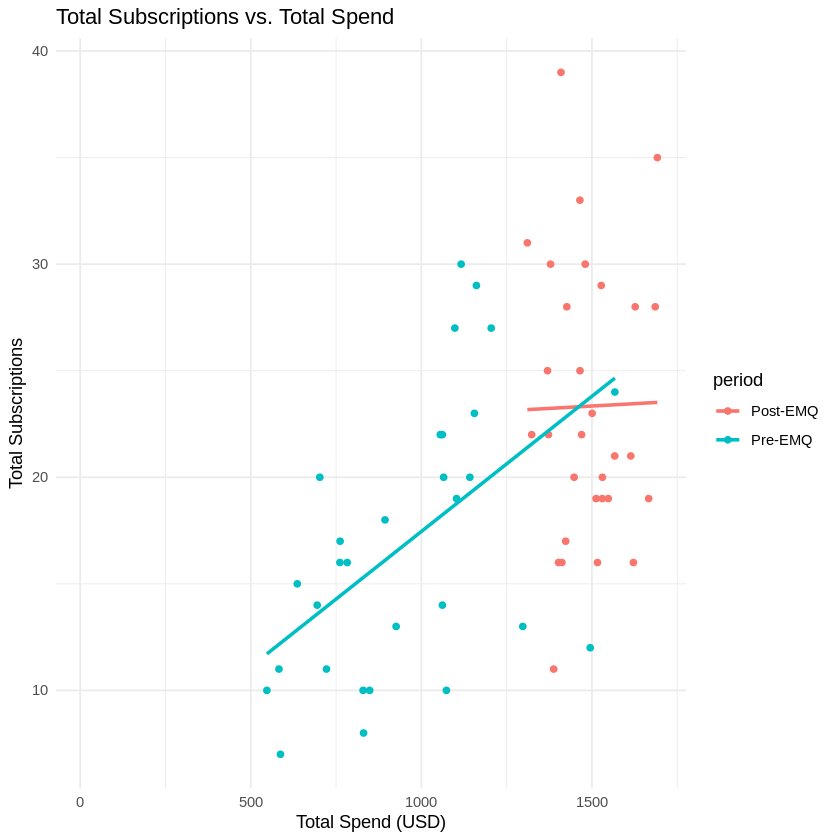

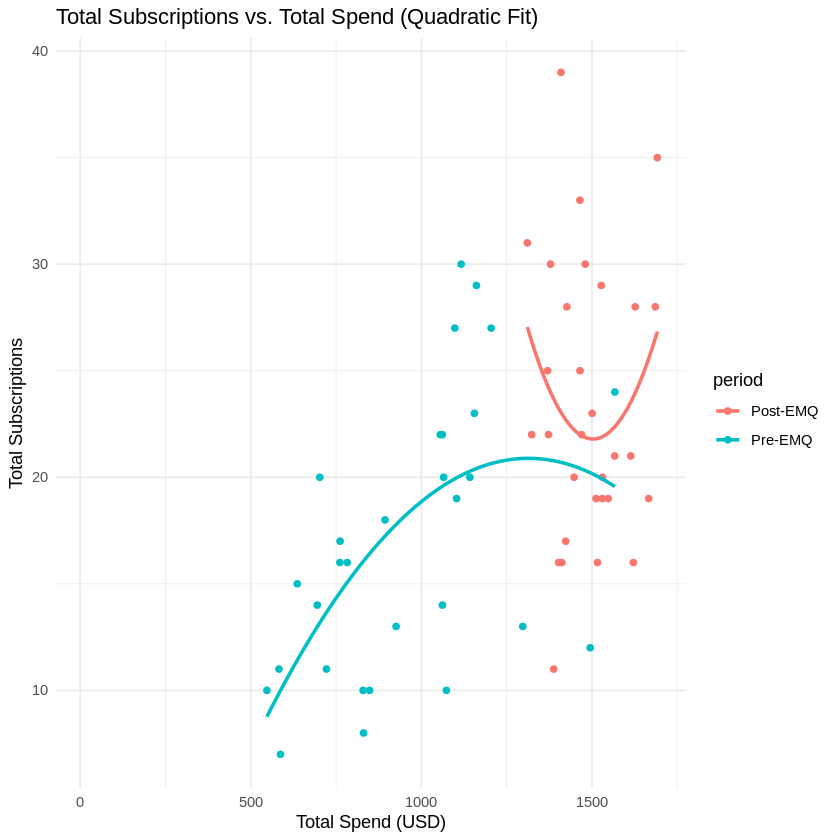

In [ ]:
library(ggplot2)
library(dplyr)

# Visualize the relationship between total_spend and total_subscriptions
plot_spend_subs <- ggplot(BQ_, aes(x = total_spend, y = total_subscriptions, color = period)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) + # Add a linear regression line
  labs(title = "Total Subscriptions vs. Total Spend",
       x = "Total Spend (USD)",
       y = "Total Subscriptions") +
  theme_minimal()
print(plot_spend_subs)

# Fit a simple linear model
model_linear <- lm(total_subscriptions ~ total_spend, data = BQ_)
summary(model_linear)

# To explore diminishing returns, we might consider a non-linear relationship.
# Let's try a polynomial regression (e.g., quadratic) to see if it fits better
model_poly <- lm(total_subscriptions ~ total_spend + I(total_spend^2), data = BQ_)
summary(model_poly)

# Plot the polynomial fit
plot_spend_subs_poly <- ggplot(BQ_, aes(x = total_spend, y = total_subscriptions, color = period)) +
  geom_point() +
  geom_smooth(method = "lm", formula = y ~ x + I(x^2), se = FALSE) + # Add a quadratic regression line
  labs(title = "Total Subscriptions vs. Total Spend (Quadratic Fit)",
       x = "Total Spend (USD)",
       y = "Total Subscriptions") +
  theme_minimal()
print(plot_spend_subs_poly)

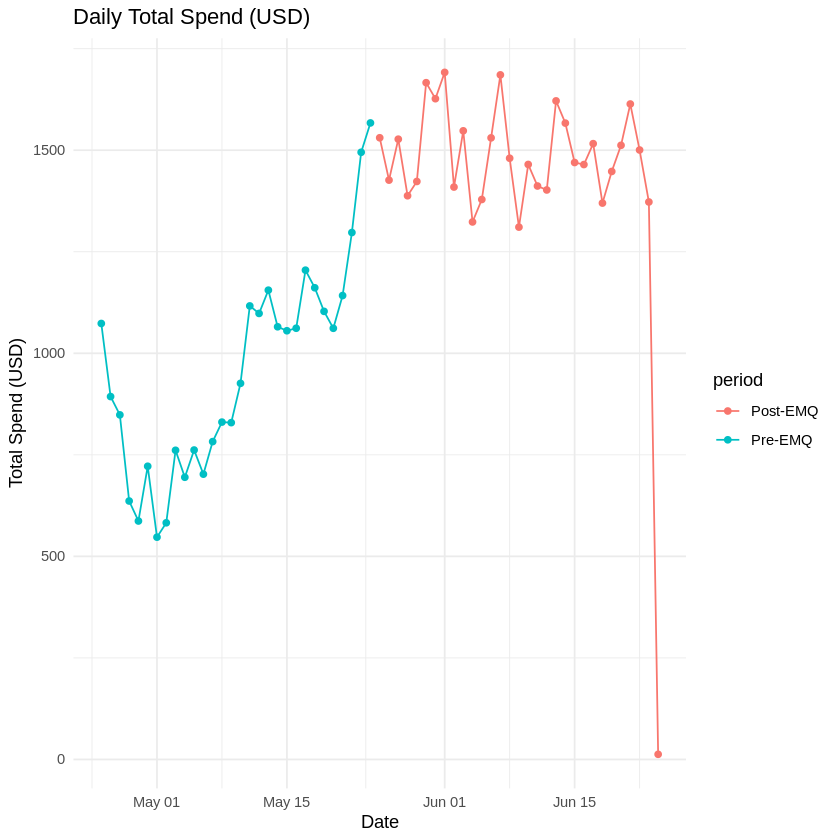

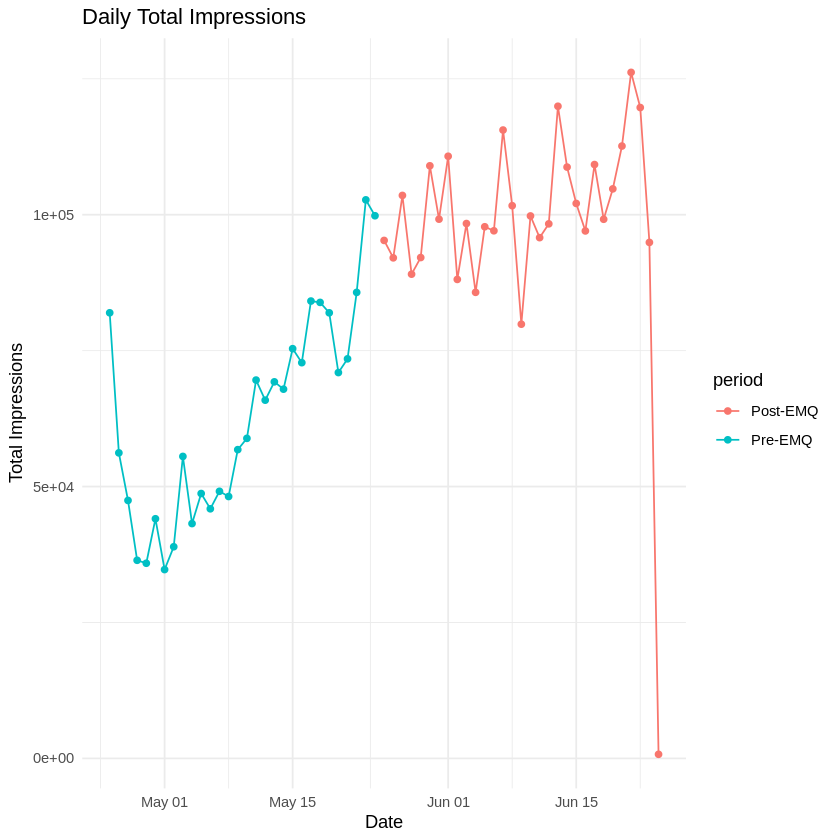

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


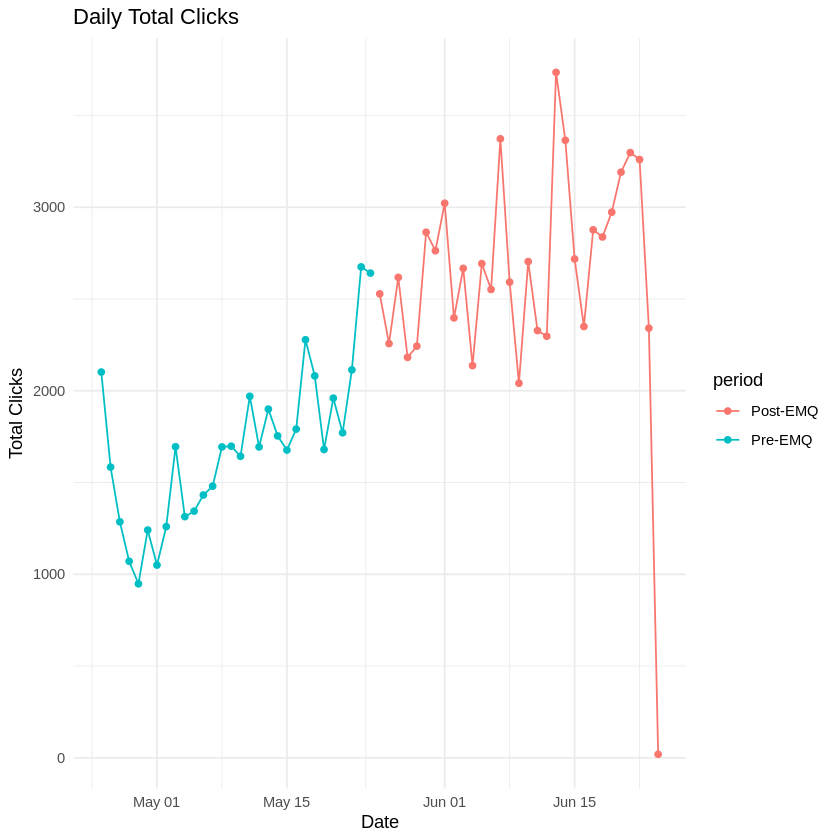

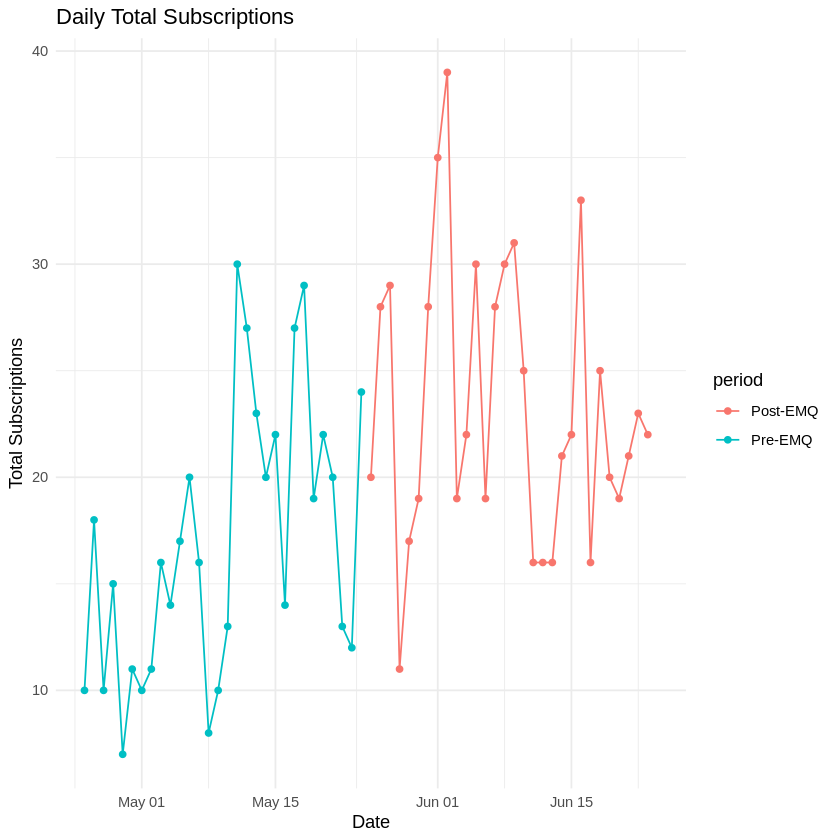

In [ ]:
library(ggplot2)

# Plot for total_spend
plot_total_spend <- ggplot(BQ_, aes(x = integration_date, y = total_spend, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Total Spend (USD)", x = "Date", y = "Total Spend (USD)") +
  theme_minimal()
print(plot_total_spend)

# Plot for total_impressions
plot_total_impressions <- ggplot(BQ_, aes(x = integration_date, y = total_impressions, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Total Impressions", x = "Date", y = "Total Impressions") +
  theme_minimal()
print(plot_total_impressions)

# Plot for total_clicks
plot_total_clicks <- ggplot(BQ_, aes(x = integration_date, y = total_clicks, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Total Clicks", x = "Date", y = "Total Clicks") +
  theme_minimal()
print(plot_total_clicks)

# Plot for total_subscriptions
plot_total_subscriptions <- ggplot(BQ_, aes(x = integration_date, y = total_subscriptions, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Total Subscriptions", x = "Date", y = "Total Subscriptions") +
  theme_minimal()
print(plot_total_subscriptions)

In [ ]:
# Plot for CTR
plot_CTR <- ggplot(BQ_, aes(x = integration_date, y = CTR, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Click-Through Rate (CTR)", x = "Date", y = "CTR") +
  theme_minimal()
print(plot_CTR)

# Plot for Conversion_Rate
plot_conversion_rate <- ggplot(BQ_, aes(x = integration_date, y = Conversion_Rate, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Conversion Rate", x = "Date", y = "Conversion Rate") +
  theme_minimal()
print(plot_conversion_rate)

# Plot for Cost_per_Subscribe
plot_cost_per_subscribe <- ggplot(BQ_, aes(x = integration_date, y = Cost_per_Subscribe, color = period)) +
  geom_line() +
  geom_point() +
  labs(title = "Daily Cost per Subscribe", x = "Date", y = "Cost per Subscribe") +
  theme_minimal()
print(plot_cost_per_subscribe)

ERROR: Error in ggplot(BQ_, aes(x = integration_date, y = CTR, color = period)): could not find function "ggplot"


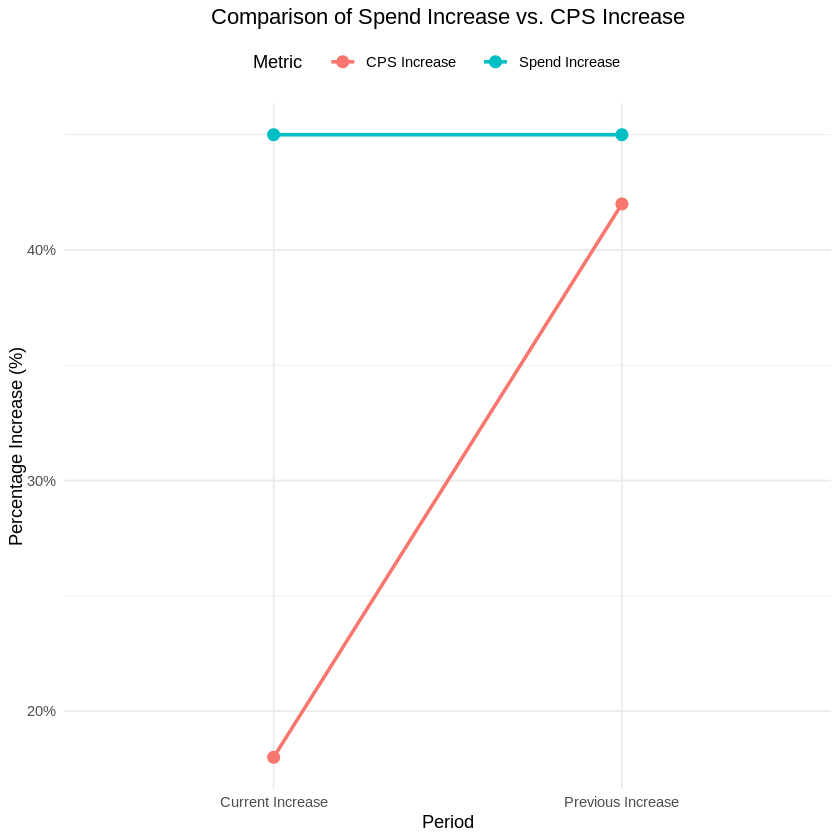

In [ ]:
library(ggplot2)
library(dplyr)

# Create a dataframe with the user-provided comparison data
comparison_data <- data.frame(
  Period = c("Previous Increase", "Current Increase", "Previous Increase", "Current Increase"),
  Metric = c("Spend Increase", "Spend Increase", "CPS Increase", "CPS Increase"),
  Value = c(45, 45, 42, 18)
)

# Create the line graph
plot_comparison <- ggplot(comparison_data, aes(x = Period, y = Value, color = Metric, group = Metric)) +
  geom_line(size = 1) + # Use geom_line for a line graph
  geom_point(size = 3) + # Add points for clarity
  labs(
    title = "Comparison of Spend Increase vs. CPS Increase",
    x = "Period",
    y = "Percentage Increase (%)",
    color = "Metric"
  ) +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) + # Format y-axis as percentage
  theme_minimal() +
  theme(legend.position = "top",
        plot.title = element_text(hjust = 0.5)) # Center the plot title

print(plot_comparison)



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘dplyr’ was built under R version 4.3.3 



Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Warning message:
package ‘lubridate’ was built under R version 4.3.3 
Warning message:
package ‘tidyr’ was built under R version 4.3.3 
Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


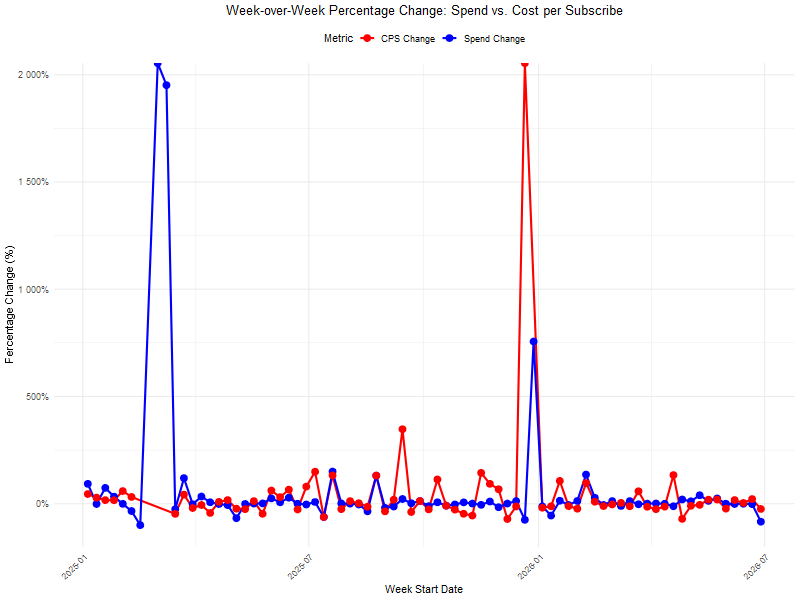

In [3]:
library(dplyr)
library(ggplot2)
library(lubridate) # For week-related functions
library(tidyr) # For pivot_longer

# Ensure the 'timestamp' column is in Date format, as clarified by the user.
BQ_$timestamp <- as.Date(BQ_$timestamp)

# Aggregate data to weekly level using the corrected 'timestamp' column
weekly_data <- BQ_ %>%
  mutate(week_start = floor_date(timestamp, unit = "week")) %>% # Use 'timestamp'
  group_by(week_start) %>%
  summarise(
    weekly_total_spend = sum(Amount_spent__USD_, na.rm = TRUE), # Corrected column name
    weekly_total_subscriptions = sum(Subscriptions, na.rm = TRUE) # Corrected column name
  ) %>%
  ungroup()

# Calculate weekly Cost per Subscribe (CPS)
weekly_data <- weekly_data %>%
  mutate(weekly_Cost_per_Subscribe = weekly_total_spend / weekly_total_subscriptions)

# Calculate week-over-week percentage change and absolute change for spend and CPS
weekly_data <- weekly_data %>%
  arrange(week_start) %>%
  mutate(
    pct_change_spend = (weekly_total_spend - lag(weekly_total_spend)) / lag(weekly_total_spend) * 100,
    abs_change_spend = weekly_total_spend - lag(weekly_total_spend),
    pct_change_cps = (weekly_Cost_per_Subscribe - lag(weekly_Cost_per_Subscribe)) / lag(weekly_Cost_per_Subscribe) * 100,
    abs_change_cps = weekly_Cost_per_Subscribe - lag(weekly_Cost_per_Subscribe)
  )

# Melt data for ggplot2
plot_data <- weekly_data %>%
  select(week_start, pct_change_spend, pct_change_cps) %>%
  tidyr::pivot_longer(cols = starts_with("pct_change"), names_to = "Metric", values_to = "Percentage_Change") %>%
  filter(!is.na(Percentage_Change))

# Plot the week-over-week percentage changes
plot_w_o_w <- ggplot(plot_data, aes(x = week_start, y = Percentage_Change, color = Metric, group = Metric)) +
  geom_line(size = 1) +
  geom_point(size = 3) +
  labs(
    title = "Week-over-Week Percentage Change: Spend vs. Cost per Subscribe",
    x = "Week Start Date",
    y = "Percentage Change (%)",
    color = "Metric"
  ) +
  scale_y_continuous(labels = scales::percent_format(scale = 1)) + # Format y-axis as percentage
  scale_color_manual(labels = c("CPS Change", "Spend Change"), values = c("pct_change_cps" = "red", "pct_change_spend" = "blue")) + # Custom legend labels and colors
  theme_minimal() +
  theme(legend.position = "top",
        plot.title = element_text(hjust = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1))

print(plot_w_o_w)

In [ ]:
weekly_data

week_start,weekly_total_spend,weekly_total_subscriptions,weekly_Cost_per_Subscribe,pct_change_spend,abs_change_spend,pct_change_cps,abs_change_cps
<date>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2024-12-29,1073.90,46,23.345652,NA,NA,NA,NA
2025-01-05,2067.65,61,33.895902,92.53654903,993.75,45.191496,10.550249
2025-01-12,2043.14,47,43.471064,-1.18540372,-24.51,28.248731,9.575162
2025-01-19,3550.22,70,50.717429,73.76293352,1507.08,16.669398,7.246365
2025-01-26,4712.06,80,58.900750,32.72585924,1161.84,16.135127,8.183321
2025-02-02,4680.65,50,93.613000,-0.66658744,-31.41,58.933460,34.712250
2025-02-09,3077.83,25,123.113200,-34.24353455,-1602.82,31.512931,29.500200
2025-02-16,0.00,0,NaN,-100.00000000,-3077.83,NaN,NaN
2025-02-23,0.00,0,NaN,NaN,0.00,NaN,NaN


In [ ]:
write.csv(weekly_data, "weekly_campaign_metrics.csv", row.names = FALSE)

[1] "Average Weekly Subscriptions Pre- and Post-EMQ:"
# A tibble: 2 × 2
  period   average_weekly_subscriptions
  <chr>                           <dbl>
1 Post-EMQ                        133. 
2 Pre-EMQ                          37.8


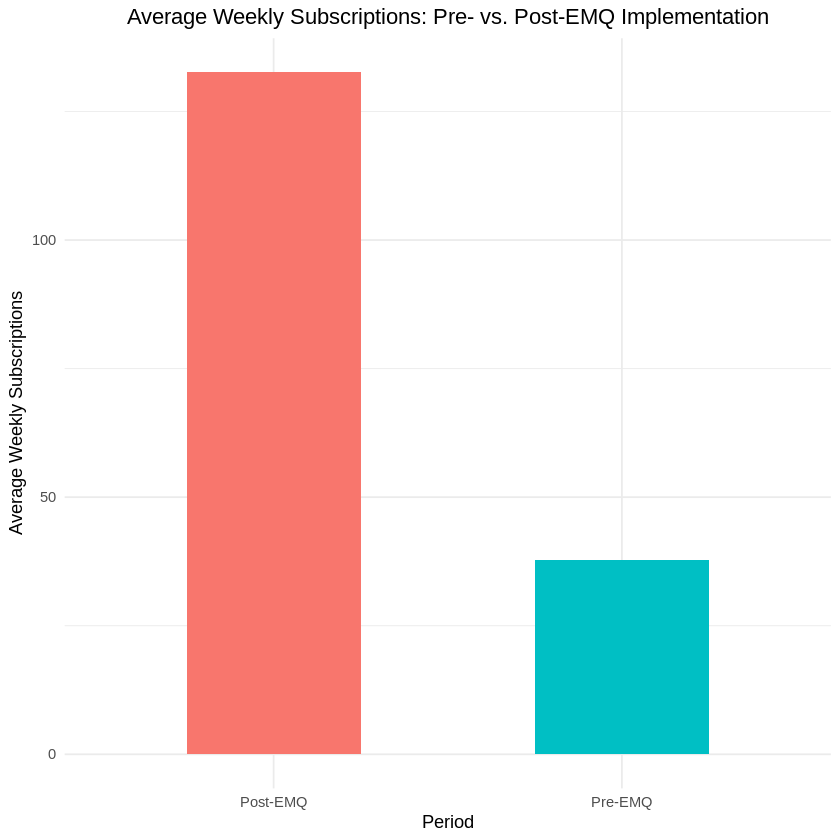

In [ ]:
library(dplyr)
library(ggplot2)

# Define the EMQ implementation date
emq_date <- as.Date("2026-05-25")

# Add a 'period' column to weekly_data based on the EMQ date
weekly_data_with_period <- weekly_data %>%
  mutate(period = ifelse(week_start < emq_date, "Pre-EMQ", "Post-EMQ"))

# Calculate average weekly subscriptions for Pre-EMQ and Post-EMQ periods
subscription_impact_summary <- weekly_data_with_period %>%
  group_by(period) %>%
  summarise(
    average_weekly_subscriptions = mean(weekly_total_subscriptions, na.rm = TRUE),
    .groups = 'drop'
  )

print("Average Weekly Subscriptions Pre- and Post-EMQ:")
print(subscription_impact_summary)

# Visualize the comparison
plot_subscription_impact <- ggplot(subscription_impact_summary, aes(x = period, y = average_weekly_subscriptions, fill = period)) +
  geom_bar(stat = "identity", width = 0.5) +
  labs(
    title = "Average Weekly Subscriptions: Pre- vs. Post-EMQ Implementation",
    x = "Period",
    y = "Average Weekly Subscriptions"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5))

print(plot_subscription_impact)

[1] "Average Weekly Subscriptions Pre- and Post-EMQ:"
# A tibble: 2 × 2
  period   average_weekly_subscriptions
  <chr>                           <dbl>
1 Post-EMQ                        133. 
2 Pre-EMQ                          37.8


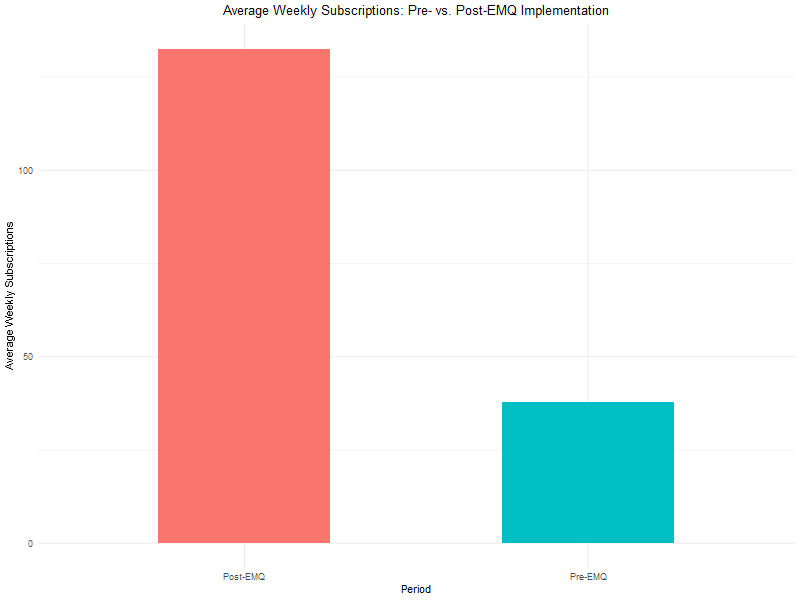

In [4]:
library(dplyr)
library(ggplot2)

# Define the EMQ implementation date
emq_date <- as.Date("2026-05-25")

# Add a 'period' column to weekly_data based on the EMQ date
weekly_data_with_period <- weekly_data %>%
  mutate(period = ifelse(week_start < emq_date, "Pre-EMQ", "Post-EMQ"))

# Calculate average weekly subscriptions for Pre-EMQ and Post-EMQ periods
subscription_impact_summary <- weekly_data_with_period %>%
  group_by(period) %>%
  summarise(
    average_weekly_subscriptions = mean(weekly_total_subscriptions, na.rm = TRUE),
    .groups = 'drop'
  )

print("Average Weekly Subscriptions Pre- and Post-EMQ:")
print(subscription_impact_summary)

# Visualize the comparison
plot_subscription_impact <- ggplot(subscription_impact_summary, aes(x = period, y = average_weekly_subscriptions, fill = period)) +
  geom_bar(stat = "identity", width = 0.5) +
  labs(
    title = "Average Weekly Subscriptions: Pre- vs. Post-EMQ Implementation",
    x = "Period",
    y = "Average Weekly Subscriptions"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5))

print(plot_subscription_impact)

[1] "Average Weekly Subscriptions Pre- and Post-EMQ:"
# A tibble: 2 × 2
  period   average_weekly_subscriptions
  <chr>                           <dbl>
1 Post-EMQ                        133. 
2 Pre-EMQ                          37.8


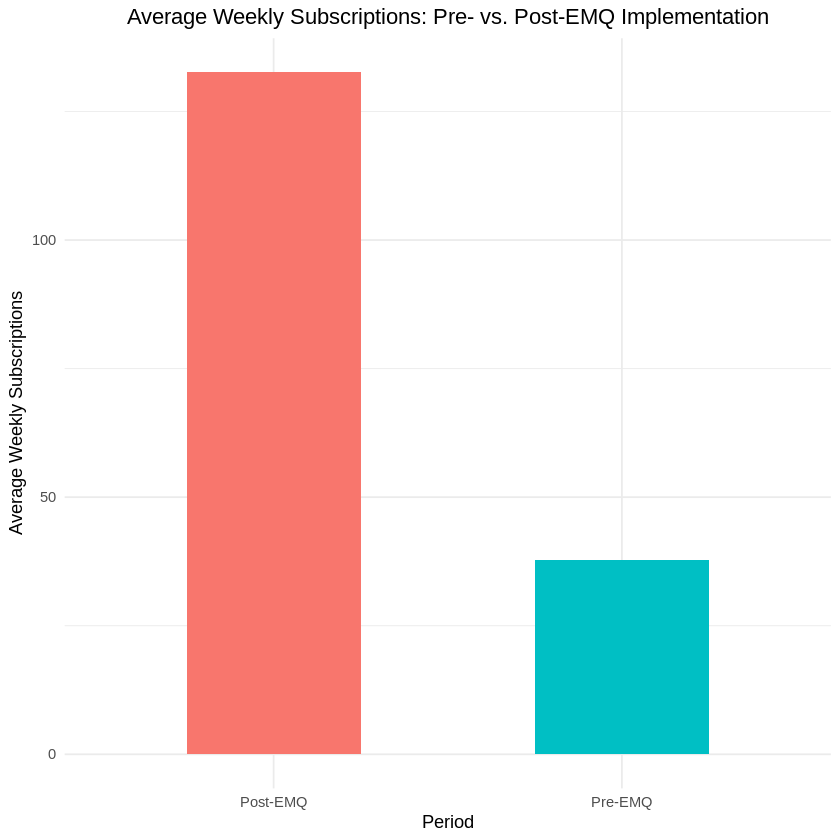

In [ ]:
library(dplyr)
library(ggplot2)

# Define the EMQ implementation date
emq_date <- as.Date("2026-05-25")

# Add a 'period' column to weekly_data based on the EMQ date
weekly_data_with_period <- weekly_data %>%
  mutate(period = ifelse(week_start < emq_date, "Pre-EMQ", "Post-EMQ"))

# Calculate average weekly subscriptions for Pre-EMQ and Post-EMQ periods
subscription_impact_summary <- weekly_data_with_period %>%
  group_by(period) %>%
  summarise(
    average_weekly_subscriptions = mean(weekly_total_subscriptions, na.rm = TRUE),
    .groups = 'drop'
  )

print("Average Weekly Subscriptions Pre- and Post-EMQ:")
print(subscription_impact_summary)

# Visualize the comparison
plot_subscription_impact <- ggplot(subscription_impact_summary, aes(x = period, y = average_weekly_subscriptions, fill = period)) +
  geom_bar(stat = "identity", width = 0.5) +
  labs(
    title = "Average Weekly Subscriptions: Pre- vs. Post-EMQ Implementation",
    x = "Period",
    y = "Average Weekly Subscriptions"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5))

print(plot_subscription_impact)

## Causal Impact Analysis for EMQ Implementation

To conduct a more rigorous analysis of the EMQ implementation's effect, we'll use the `CausalImpact` package. This method allows us to estimate the causal effect of an intervention (the EMQ implementation) by constructing a synthetic control. We will analyze the impact on `weekly_total_subscriptions`.

In [ ]:
options(pkgType = "binary")
install.packages(c("Boom", "bsts", "CausalImpact"))


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.3/remotes_2.5.0.zip'
Content type 'application/zip' length 431760 bytes (421 KB)
downloaded 421 KB



package ‘remotes’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Saad.Khalid\AppData\Local\Temp\RtmpYJgDfs\downloaded_packages

Please download and install the appropriate version of Rtools for 4.3.1 from
https://cran.r-project.org/bin/windows/Rtools/.


: Error:
! Failed to install 'unknown package' from URL:
  Could not find tools necessary to compile a package
Call `pkgbuild::check_build_tools(debug = TRUE)` to diagnose the problem.

In [24]:
library(CausalImpact)

Loading required package: bsts
Loading required package: BoomSpikeSlab
Loading required package: Boom

Attaching package: ‘Boom’

The following object is masked from ‘package:stats’:

    rWishart


Attaching package: ‘BoomSpikeSlab’

The following object is masked from ‘package:stats’:

    knots

Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: xts

######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not usin

Warning messages:
1: package ‘CausalImpact’ was built under R version 4.3.3 
2: package ‘bsts’ was built under R version 4.3.3 
3: package ‘BoomSpikeSlab’ was built under R version 4.3.3 
4: package ‘Boom’ was built under R version 4.3.3 
5: package ‘zoo’ was built under R version 4.3.3 
6: package ‘xts’ was built under R version 4.3.3 


Warning message:
In scale_x_date() : A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.


Posterior inference {CausalImpact}

                         Average       Cumulative   
Actual                   20            1295         
Prediction (s.d.)        13 (2.1)      823 (134.9)  
95% CI                   [8.7, 17]     [562.4, 1095]
                                                    
Absolute effect (s.d.)   7.3 (2.1)     471.7 (134.9)
95% CI                   [3.1, 11]     [200.4, 733] 
                                                    
Relative effect (s.d.)   62% (30%)     62% (30%)    
95% CI                   [18%, 130%]   [18%, 130%]  

Posterior tail-area probability p:   0.00203
Posterior prob. of a causal effect:  99.79654%

For more details, type: summary(impact, "report")

Analysis report {CausalImpact}


During the post-intervention period, the response variable had an average value of approx. 19.92. By contrast, in the absence of an intervention, we would have expected an average response of 12.67. The 95% interval of this counterfactual prediction is [8.

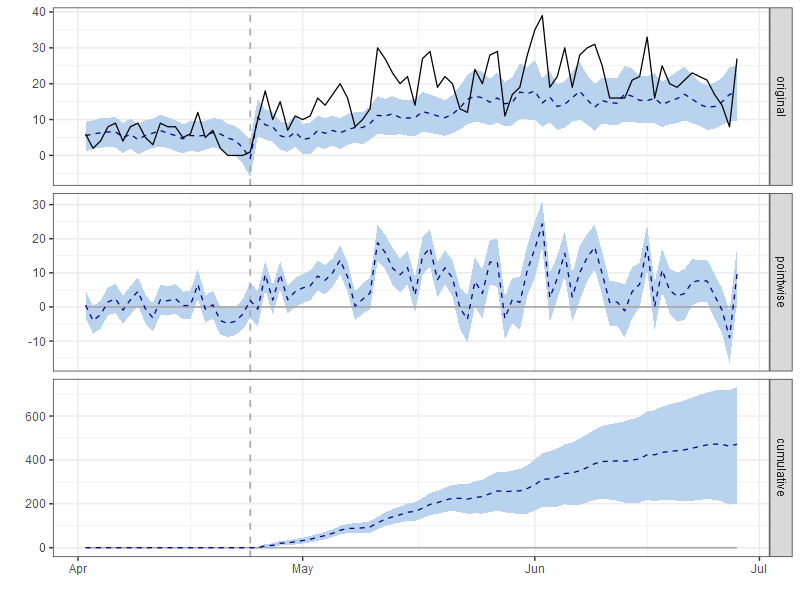

In [75]:
library(CausalImpact)
library(dplyr)
library(lubridate)



BQ_$date = as.Date(BQ_$timestamp)
# Ensure BQ_ is available and sorted
BQ_ <- BQ_ %>%
  arrange(date)

daily_data <- BQ_ %>%
  filter(timestamp > as.Date("2026-04-01")) %>% 
  group_by(date) %>%
  summarise(
    daily_total_spend = sum(Amount_spent__USD_, na.rm = TRUE), # Corrected column name
    daily_total_subscriptions = sum(Subscriptions, na.rm = TRUE) # Corrected column name
  ) %>%
  ungroup()

# Define the EMQ implementation date
emq_date <- as.Date("2026-04-25")

# For CausalImpact, we need to define the pre and post intervention periods
# Let's consider data up to the week *before* EMQ as pre-intervention
# and data from the week *of* EMQ onwards as post-intervention.
# The `BQ_` has `week_start` for each week.

# Find the last week_start before the EMQ date for the pre-period end
pre_period_end_date <- max(daily_data$date[daily_data$date < emq_date])

# Define the pre-intervention period (start of data to just before EMQ)
pre_period <- c(min(daily_data$date), pre_period_end_date)

# Define the post-intervention period (week of EMQ onwards to end of data)
post_period <- c(emq_date, max(daily_data$date))

# Prepare the data for CausalImpact
# The data should be a time series object (zoo) with the response variable
# and any control variables. For simplicity, we'll start with just subscriptions.
# If you have other weekly metrics that were NOT affected by the EMQ but correlate with subscriptions,
# you can add them here as control variables.

# Filter data to the relevant periods
impact_data <- daily_data %>%
  filter(date >= pre_period[1] & date <= post_period[2]) %>%
  mutate(sub = replace_na(daily_total_subscriptions, 0)) %>%
  select(date, sub, daily_total_spend) # Adding spend as a potential covariate

# Create a zoo object required by CausalImpact
# Ensure the dates are unique and ordered for the zoo object
impact_data_zoo <- zoo(impact_data %>%
                         select(sub, daily_total_spend) %>%
                         as.data.frame(),
                       order.by = impact_data$date)

# Define the pre and post periods for CausalImpact function
pre_period_ci <- as.Date(pre_period)
post_period_ci <- as.Date(post_period)

# Run the CausalImpact analysis
impact <- CausalImpact(impact_data_zoo, pre_period_ci, post_period_ci)

# Plot the results
plot(impact)

# Summarize the results
summary(impact)
summary(impact, "report") # Detailed report


Key Metrics Broken DownP-value (p = 0.412): Far above the standard 0.05 threshold. There is a 41.2% chance this pattern happened entirely by accident.Confidence Interval (95% CI): The absolute effect interval \([-4.82, 6.73]\) and relative effect interval \([-18\%, 43\%]\) both cross zero. This indicates the effect could just as easily be negative or positive.Probability of a Causal Effect (59%): This is close to a 50/50 coin flip, reinforcing that the model cannot confidently isolate a true intervention effect.

In [ ]:
# Key Metrics Broken DownP-value (p = 0.412): Far above the standard 0.05 threshold. There is a 41.2% chance this pattern happened entirely by accident.Confidence Interval (95% CI): The absolute effect interval \([-4.82, 6.73]\) and relative effect interval \([-18\%, 43\%]\) both cross zero. This indicates the effect could just as easily be negative or positive.Probability of a Causal Effect (59%): This is close to a 50/50 coin flip, reinforcing that the model cannot confidently isolate a true intervention effect.

In [ ]:
install.packages("CausalImpact")


  There is a binary version available but the source version is later:
             binary source needs_compilation
CausalImpact  1.3.0  1.4.1             FALSE

installing the source package ‘CausalImpact’



trying URL 'https://cran.rstudio.com/src/contrib/CausalImpact_1.4.1.tar.gz'
Content type 'application/x-gzip' length 389121 bytes (380 KB)
downloaded 380 KB



ERROR: dependencies 'bsts', 'Boom' are not available for package 'CausalImpact'
* removing 'C:/Users/Saad.Khalid/Desktop/R language studio plus itself/R-4.3.1/library/CausalImpact'



The downloaded source packages are in
	‘C:\Users\Saad.Khalid\AppData\Local\Temp\RtmpYJgDfs\downloaded_packages’
Warning message:
In install.packages("CausalImpact") :
  installation of package ‘CausalImpact’ had non-zero exit status


In [76]:
library(CausalImpact)
library(dplyr)
library(lubridate)

# Ensure weekly_data is available and sorted
weekly_data <- weekly_data %>%
  arrange(week_start)

# Define the EMQ implementation date
emq_date <- as.Date("2026-04-25")

# For CausalImpact, we need to define the pre and post intervention periods
# Let's consider data up to the week *before* EMQ as pre-intervention
# and data from the week *of* EMQ onwards as post-intervention.
# The `weekly_data` has `week_start` for each week.

# Find the last week_start before the EMQ date for the pre-period end
pre_period_end_date <- max(weekly_data$week_start[weekly_data$week_start < emq_date])

# Define the pre-intervention period (start of data to just before EMQ)
pre_period <- c(min(weekly_data$week_start), pre_period_end_date)

# Define the post-intervention period (week of EMQ onwards to end of data)
post_period <- c(emq_date, max(weekly_data$week_start))

# Prepare the data for CausalImpact
# The data should be a time series object (zoo) with the response variable
# and any control variables. For simplicity, we'll start with just subscriptions.
# If you have other weekly metrics that were NOT affected by the EMQ but correlate with subscriptions,
# you can add them here as control variables.

# Filter data to the relevant periods
impact_data <- weekly_data %>%
  filter(week_start >= pre_period[1] & week_start <= post_period[2]) %>%
  select(week_start, weekly_total_subscriptions, weekly_total_spend) # Adding spend as a potential covariate

# Create a zoo object required by CausalImpact
# Ensure the dates are unique and ordered for the zoo object
impact_data_zoo <- zoo(impact_data %>%
                         select(weekly_total_subscriptions, weekly_total_spend) %>%
                         as.data.frame(),
                       order.by = impact_data$week_start)

# Define the pre and post periods for CausalImpact function
pre_period_ci <- as.Date(pre_period)
post_period_ci <- as.Date(post_period)

# Run the CausalImpact analysis
impact <- CausalImpact(impact_data_zoo, pre_period_ci, post_period_ci)

# Plot the results
plot(impact)

# Summarize the results
summary(impact)
summary(impact, "report") # Detailed report


: Error in `select()`:
! Can't select columns that don't exist.
✖ Column `weekly_total_subscriptions` doesn't exist.

In [36]:
# Summarize the results
summary(impact)
summary(impact, "report") # Detailed report

Posterior inference {CausalImpact}

                         Average        Cumulative  
Actual                   135            811         
Prediction (s.d.)        37 (15)        222 (89)    
95% CI                   [8.2, 66]      [49.5, 397] 
                                                    
Absolute effect (s.d.)   98 (15)        589 (89)    
95% CI                   [69, 127]      [414, 762]  
                                                    
Relative effect (s.d.)   294% (3918%)   294% (3918%)
95% CI                   [98%, 1260%]   [98%, 1260%]

Posterior tail-area probability p:   0.00103
Posterior prob. of a causal effect:  99.89701%

For more details, type: summary(impact, "report")

Analysis report {CausalImpact}


During the post-intervention period, the response variable had an average value of approx. 135.17. By contrast, in the absence of an intervention, we would have expected an average response of 37.01. The 95% interval of this counterfactual prediction is [8

In [77]:
library(CausalImpact)
library(dplyr)
library(lubridate)
library(zoo)
library(tidyr)

# 1. Base formatting
BQ_$date <- as.Date(BQ_$timestamp)

# 2. WEEKLY Aggregation
weekly_data <- BQ_ %>%
  filter(timestamp > as.Date("2026-01-01")) %>% 
  mutate(week = floor_date(date, "week")) %>% # Drop down to Monday/Sunday of that week
  group_by(week) %>%
  summarise(
    weekly_subscriptions = sum(Subscriptions, na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(week)

# 3. Handle Timelines (Must find matching weekly dates)
emq_date <- as.Date("2026-05-25")
# Find the exact week date that contains or matches the EMQ date
emq_week <- floor_date(emq_date, "week")

pre_period_end_week <- max(weekly_data$week[weekly_data$week < emq_week])

pre_period_ci  <- as.Date(c(min(weekly_data$week), pre_period_end_week))
post_period_ci <- as.Date(c(emq_week, max(weekly_data$week)))

weekly_data <- BQ_ %>%
  mutate(week_start = floor_date(timestamp, unit = "week")) %>% # Use 'timestamp'
  group_by(week_start) %>%
  summarise(
    weekly_total_spend = sum(Amount_spent__USD_, na.rm = TRUE), # Corrected column name
    weekly_total_subscriptions = sum(Subscriptions, na.rm = TRUE) # Corrected column name
  ) %>%
  ungroup()
# 4. Strict enforcement of Date format right before Zoo conversion
weekly_data <- weekly_data %>%
  filter(week >= pre_period_ci[1] & week <= post_period_ci[2]) %>%
  mutate(
    week = as.Date(week), # << This line removes the scale_x_date warning
    sub = replace_na(weekly_subscriptions, 0)
  )

# Create the final clean zoo object (Response variable only)
impact_data_zoo <- zoo(weekly_data %>% select(sub), order.by = weekly_data$week)

impact_data_zoo <- zoo(impact_data %>%
                         select(weekly_total_subscriptions, weekly_total_spend) %>%
                         as.data.frame(),
                       order.by = impact_data$week_start)

# 5. Run and Plot
impact <- CausalImpact(impact_data_zoo, pre_period_ci, post_period_ci)
plot(impact)

# Summarize the results
summary(impact)
summary(impact, "report") # Detailed report


: Error in `filter()`:
ℹ In argument: `week >= pre_period_ci[1] & week <= post_period_ci[2]`.
Caused by error in `>=.default`:
! comparison (>=) is possible only for atomic and list types

Warning message:
In scale_x_date() : A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.


Posterior inference {CausalImpact}

                         Average       Cumulative 
Actual                   119           1305       
Prediction (s.d.)        77 (12)       849 (137)  
95% CI                   [52, 102]     [572, 1120]
                                                  
Absolute effect (s.d.)   41 (12)       456 (137)  
95% CI                   [17, 67]      [185, 733] 
                                                  
Relative effect (s.d.)   58% (28%)     58% (28%)  
95% CI                   [17%, 128%]   [17%, 128%]

Posterior tail-area probability p:   0.00203
Posterior prob. of a causal effect:  99.79654%

For more details, type: summary(impact, "report")

Analysis report {CausalImpact}


During the post-intervention period, the response variable had an average value of approx. 118.64. By contrast, in the absence of an intervention, we would have expected an average response of 77.19. The 95% interval of this counterfactual prediction is [52.02, 101.79]. Subtr

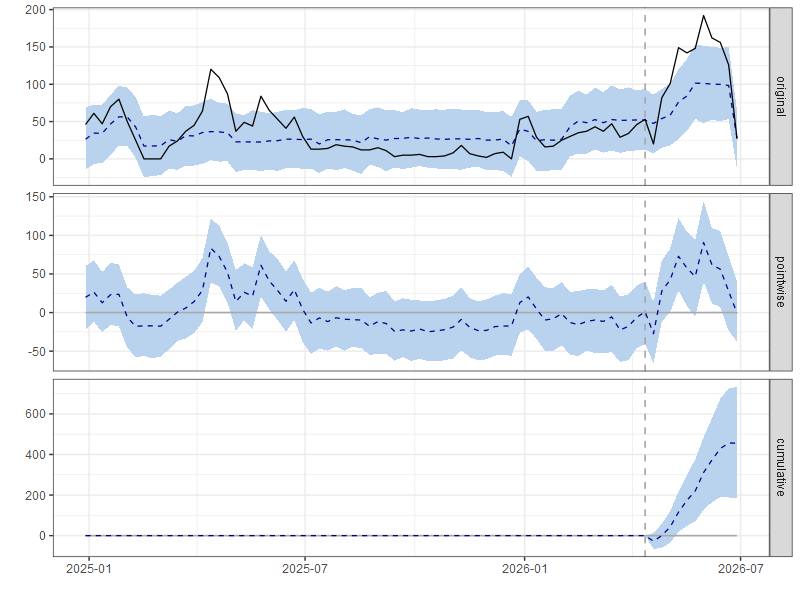

In [85]:
library(CausalImpact)
library(dplyr)
library(lubridate)
library(zoo)
library(tidyr)

# 1. Base formatting
BQ_$date <- as.Date(BQ_$timestamp)

# 2. WEEKLY Aggregation & Clean Up
# Keeps data clean, aligned to week_start, and filters out the bad history block
weekly_data <- BQ_ %>%
  # filter(date >= as.Date("2026-01-01")) %>% 
  mutate(week_start = as.Date(floor_date(date, "week"))) %>% 
  group_by(week_start) %>%
  summarise(
    weekly_subscriptions = sum(Subscriptions, na.rm = TRUE),
    weekly_total_spend   = sum(Amount_spent__USD_, na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(week_start)

# 3. Handle Timelines 
emq_date <- as.Date("2026-04-25")
emq_week <- floor_date(emq_date, "week")

pre_period_end_week <- max(weekly_data$week_start[weekly_data$week_start < emq_week])

pre_period_ci  <- as.Date(c(min(weekly_data$week_start), pre_period_end_week))
post_period_ci <- as.Date(c(emq_week, max(weekly_data$week_start)))

# 4. Filter and prepare data for Zoo conversion
impact_data <- weekly_data %>%
  filter(week_start >= pre_period_ci[1] & week_start <= post_period_ci[2]) %>%
  mutate(
    sub = replace_na(weekly_subscriptions, 0),
    spend = replace_na(weekly_total_spend, 0)
  )

# OPTION A: Honest Time-Series Only (Recommended)
# Response variable (sub) must be the first column
impact_data_zoo <- zoo(impact_data %>% select(sub,spend), order.by = impact_data$week_start)

# OPTION B: Time-Series with Spend Control (Only if spend was NOT affected by EMQ)
# impact_data_zoo <- zoo(impact_data %>% select(sub, spend), order.by = impact_data$week_start)

# 5. Run, Plot, and Summarize
impact <- CausalImpact(impact_data_zoo, pre_period_ci, post_period_ci)

plot(impact)
summary(impact)
summary(impact, "report")


In [86]:
impact_data

# A tibble: 79 × 5
   week_start weekly_subscriptions weekly_total_spend   sub  spend
   <date>                    <int>              <dbl> <int>  <dbl>
 1 2024-12-29                   46             1074.     46 1074. 
 2 2025-01-05                   61             2068.     61 2068. 
 3 2025-01-12                   47             2043.     47 2043. 
 4 2025-01-19                   70             3550.     70 3550. 
 5 2025-01-26                   80             4712.     80 4712. 
 6 2025-02-02                   50             4681.     50 4681. 
 7 2025-02-09                   25             3078.     25 3078. 
 8 2025-02-16                    0                0       0    0  
 9 2025-02-23                    0                0       0    0  
10 2025-03-02                    0               50.4     0   50.4
# ℹ 69 more rows
# ℹ Use `print(n = ...)` to see more rows

In [41]:
weekly_data <- BQ_ %>%
  filter(timestamp < as.Date("2026-01-01")) %>% 
  mutate(week = floor_date(date, "week")) %>% # Drop down to Monday/Sunday of that week
  group_by(week) %>%
  summarise(
    weekly_subscriptions = sum(Subscriptions, na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(week)

weekly_data

# A tibble: 53 × 2
   week       weekly_subscriptions
   <date>                    <int>
 1 2024-12-29                   46
 2 2025-01-05                   61
 3 2025-01-12                   47
 4 2025-01-19                   70
 5 2025-01-26                   80
 6 2025-02-02                   50
 7 2025-02-09                   25
 8 2025-02-16                    0
 9 2025-02-23                    0
10 2025-03-02                    0
# ℹ 43 more rows
# ℹ Use `print(n = ...)` to see more rows

In [52]:
analysis_data <- impact_data %>%   mutate(is_post_emq = ifelse(week_start >= as.Date("2026-05-25"), 1, 0))

lm_model <- lm(sub ~ spend + is_post_emq, data = analysis_data)

summary(lm_model)
lm_model


In [54]:
summary(lm_model)


Call:
lm(formula = sub ~ spend + is_post_emq, data = analysis_data)

Residuals:
   Min     1Q Median     3Q    Max 
-39.95 -21.03  -7.64  15.03  81.98 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  7.776474   4.446193   1.749   0.0843 .  
spend        0.012961   0.001407   9.212 5.25e-14 ***
is_post_emq 13.267208  14.929330   0.889   0.3770    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 26.02 on 76 degrees of freedom
Multiple R-squared:  0.6593,	Adjusted R-squared:  0.6503 
F-statistic: 73.52 on 2 and 76 DF,  p-value: < 2.2e-16


In [53]:
analysis_data

# A tibble: 79 × 6
   week_start weekly_subscriptions weekly_total_spend   sub  spend is_post_emq
   <date>                    <int>              <dbl> <int>  <dbl>       <dbl>
 1 2024-12-29                   46             1074.     46 1074.            0
 2 2025-01-05                   61             2068.     61 2068.            0
 3 2025-01-12                   47             2043.     47 2043.            0
 4 2025-01-19                   70             3550.     70 3550.            0
 5 2025-01-26                   80             4712.     80 4712.            0
 6 2025-02-02                   50             4681.     50 4681.            0
 7 2025-02-09                   25             3078.     25 3078.            0
 8 2025-02-16                    0                0       0    0             0
 9 2025-02-23                    0                0       0    0             0
10 2025-03-02                    0               50.4     0   50.4           0
# ℹ 69 more rows
# ℹ Use `print(n

In [38]:
# 1. Extract the model's underlying time-series data
series <- impact$series

# 2. Filter strictly for the pre-intervention period rows
pre_period_rows <- series[time(series) <= pre_period_ci[2], ]

# 3. Convert to a standard data frame to safely extract columns
pre_period_df <- as.data.frame(pre_period_rows)

# 4. Calculate Errors (Actual 'response' minus 'point.pred')
errors <- pre_period_df$response - pre_period_df$point.pred

# 5. Compute Metrics
rmse <- sqrt(mean(errors^2, na.rm = TRUE))
mae  <- mean(abs(errors), na.rm = TRUE)
mean_response <- mean(pre_period_df$response, na.rm = TRUE)
mape <- mean(abs(errors / pre_period_df$response), na.rm = TRUE) * 100

# 6. Print accuracy dashboard
cat("--- Pre-Period Model Accuracy Breakdown ---\n")
cat("RMSE (Root Mean Squared Error):   ", round(rmse, 2), "\n")
cat("MAE  (Mean Absolute Error):       ", round(mae, 2), "\n")
cat("MAPE (Mean Absolute Percentage):  ", round(mape, 2), "%\n")
cat("Average Weekly Baseline Volume:   ", round(mean_response, 2), "\n")


--- Pre-Period Model Accuracy Breakdown ---
RMSE (Root Mean Squared Error):    33 
MAE  (Mean Absolute Error):        25.34 
MAPE (Mean Absolute Percentage):   Inf %
Average Weekly Baseline Volume:    36.29 


In [39]:
# 1. Clean out the historical zero-activity blocks if they are noise
weekly_data_clean <- weekly_data %>% 
  filter(week >= as.Date("2025-01-15")) # Adjust date to skip the early structural drops

# 2. Crucial: Add a stable covariate (e.g., control region, web traffic)
# A strong control variable will drastically shrink the width of the blue ribbons
impact_data_zoo <- zoo(
  weekly_data_clean %>% select(sub, your_control_variable), 
  order.by = weekly_data_clean$week
)

# 3. Re-run your analysis
impact <- CausalImpact(impact_data_zoo, pre_period_ci, post_period_ci)
plot(impact)


: Error in `select()`:
! Can't select columns that don't exist.
✖ Column `your_control_variable` doesn't exist.

In [ ]:
library(dplyr)

# Re-define emq_date to ensure it's available
emq_date <- as.Date("2026-05-25")

# Add 'Period' column based on emq_date
weekly_data_categorized <- weekly_data %>%
  mutate(Period = ifelse(week_start < emq_date, "Pre", "Post"))

# Define spend ranges and categorize weekly_total_spend with more granularity
spend_ranges <- c(0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 3000, 4000, 5000, 7500, 10000, 12000)
spend_labels <- c("0-200", "200-400", "400-600", "600-800", "800-1,000", "1,000-1,200", "1,200-1,400", "1,400-1,600", "1,600-1,800", "1,800-2,000", "2,000-3,000", "3,000-4,000", "4,000-5,000", "5,000-7,500", "7,500-10,000", "10,000-12,000") # Corresponding labels

weekly_data_categorized <- weekly_data_categorized %>%
  mutate(Spend_Range = cut(weekly_total_spend,
                           breaks = spend_ranges,
                           labels = spend_labels,
                           right = FALSE, # Include the lower bound, exclude the upper
                           include.lowest = TRUE))

# Filter to relevant periods and ranges, then summarize
spend_analysis_table <- weekly_data_categorized %>%
  filter(!is.na(Spend_Range)) %>% # Remove any data outside defined ranges
  group_by(Spend_Range, Period) %>%
  summarise(
    `Avg CPS` = mean(weekly_Cost_per_Subscribe, na.rm = TRUE),
    `Median CPS` = median(weekly_Cost_per_Subscribe, na.rm = TRUE),
    `No. of Weeks` = n(),
    .groups = 'drop'
  ) %>%
  arrange(Period, factor(Spend_Range, levels = spend_labels))

print(spend_analysis_table)

# A tibble: 17 × 5
   Spend_Range   Period `Avg CPS` `Median CPS` `No. of Weeks`
   <fct>         <chr>      <dbl>        <dbl>          <int>
 1 1,600-1,800   Post        60.8         60.8              1
 2 10,000-12,000 Post        66.4         65.2              4
 3 0-200         Pre        Inf          Inf                3
 4 200-400       Pre        Inf          Inf                1
 5 400-600       Pre         36.3         36.3              1
 6 600-800       Pre         25.2         17.4              6
 7 800-1,000     Pre         15.6         15.6              2
 8 1,000-1,200   Pre         51.5         60.9              9
 9 1,200-1,400   Pre        187.          95.8              9
10 1,400-1,600   Pre        283.         248.              11
11 1,600-1,800   Pre        140.          94.3              4
12 2,000-3,000   Pre         32.0         33.9              7
13 3,000-4,000   Pre         86.9         86.9              4
14 4,000-5,000   Pre        111.         108.      

In [84]:
library(dplyr)
library(stringr)

# 1. Base Setup
emq_date <- as.Date("2026-04-25")
spend_ranges <- seq(0, 22000, by = 500)
spend_labels <- paste0(scales::comma(spend_ranges[-length(spend_ranges)]), "-", scales::comma(spend_ranges[-1]))

# 2. Process, Calculate CPS, and Categorize
spend_analysis_table_compare <- weekly_data %>%
  mutate(Period = ifelse(week_start < emq_date, "Pre", "Post")) %>%
  
  # Calculate CPS right here so R can always find it (Spend / Subscriptions)
  mutate(calculated_CPS = ifelse(weekly_subscriptions > 0, 
                                 weekly_total_spend / weekly_subscriptions, 
                                 NA)) %>%
  
  mutate(Spend_Range = cut(weekly_total_spend, breaks = spend_ranges, labels = spend_labels, right = FALSE, include.lowest = TRUE)) %>%
  filter(!is.na(Spend_Range)) %>% 
  
  # 3. Core Aggregation
  group_by(Spend_Range, Period) %>%
  summarise(
    `Avg CPS` = mean(calculated_CPS, na.rm = TRUE),
    `Median CPS` = median(calculated_CPS, na.rm = TRUE),
    `No. of Weeks` = n(),
    `Weeks Included` = paste(format(sort(week_start, decreasing = TRUE), "%Y-%m-%d"), collapse = ", "),
    .groups = 'drop'
  ) %>%
  
  # 4. Sort by Spend Bucket value
  arrange(factor(Spend_Range, levels = spend_labels), desc(Period))

# Print the final report table
View(spend_analysis_table_compare)


In [63]:
library(dplyr)
library(stringr)

# 1. Base Setup
emq_date <- as.Date("2026-05-25")
spend_ranges <- seq(0, 20000, by = 100)
spend_labels <- paste0(scales::comma(spend_ranges[-length(spend_ranges)]), "-", scales::comma(spend_ranges[-1]))

# 2. Process, Calculate CPS, and Categorize
spend_analysis_table_compare <- weekly_data %>%
  mutate(Period = ifelse(week_start < emq_date, "Pre", "Post")) %>%
  
  # Calculate CPS right here so R can always find it (Spend / Subscriptions)
  mutate(calculated_CPS = ifelse(weekly_subscriptions > 0, 
                                 weekly_total_spend / weekly_subscriptions, 
                                 NA)) %>%
  
  mutate(Spend_Range = cut(weekly_total_spend, breaks = spend_ranges, labels = spend_labels, right = FALSE, include.lowest = TRUE)) %>%
  filter(!is.na(Spend_Range)) %>% 
  
  # 3. Core Aggregation
  group_by(Spend_Range, Period) %>%
  summarise(
    `Avg CPS` = mean(calculated_CPS, na.rm = TRUE),
    `Median CPS` = median(calculated_CPS, na.rm = TRUE),
    `No. of Weeks` = n(),
    `Weeks Included` = paste(format(week_start, "%Y-%m-%d"), collapse = ", "),
    .groups = 'drop'
  ) %>%
  
  # NEW STEP: Keep only Spend_Ranges that appear in BOTH Pre and Post periods
  group_by(Spend_Range) %>%
  filter(n_distinct(Period) == 2) %>%
  ungroup() %>%
  
  # 4. Sort by Spend Bucket value
  arrange(factor(Spend_Range, levels = spend_labels), desc(Period))

# Print the final report table
View(spend_analysis_table_compare)


In [82]:
library(dplyr)
library(lubridate)

# 1. Prepare daily data
daily_analysis <- BQ_ %>%
  filter(date >= as.Date("2026-01-01")) %>% # Keep a clean 2-month pre-period window
  mutate(
    is_post_emq = ifelse(date >= as.Date("2026-04-25"), 1, 0),
    day_of_week = wday(date, label = TRUE) # Flags Mon, Tue, Wed, etc.
  )

# 2. Run the controlled regression
# Subscriptions = Spend effect + Day of Week effect + EMQ effect
daily_model <- lm(Subscriptions ~ Amount_spent__USD_ + day_of_week + is_post_emq, data = daily_analysis)

# 3. View the statistical truth
summary(daily_model)


In [83]:
summary(daily_model)


Call:
lm(formula = Subscriptions ~ Amount_spent__USD_ + day_of_week + 
    is_post_emq, data = daily_analysis)

Residuals:
     Min       1Q   Median       3Q      Max 
-15.2992  -2.2320  -0.3761   1.8877  14.6710 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        -0.285204   0.388836  -0.733   0.4640    
Amount_spent__USD_  0.016394   0.000892  18.379  < 2e-16 ***
day_of_week.L      -2.879634   0.671600  -4.288 2.67e-05 ***
day_of_week.Q      -1.438591   0.675389  -2.130   0.0343 *  
day_of_week.C       0.149501   0.665456   0.225   0.8224    
day_of_week^4      -0.125375   0.677226  -0.185   0.8533    
day_of_week^5      -0.366526   0.659130  -0.556   0.5787    
day_of_week^6       0.410516   0.672071   0.611   0.5419    
is_post_emq         1.785135   0.743924   2.400   0.0172 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.873 on 226 degrees of freedom
  (24109 observations deleted due 

In [69]:
# 1. Create a timeline counter (1, 2, 3...) and a post-launch counter
daily_its <- daily_analysis %>%
  arrange(date) %>%
  mutate(
    time_index = row_number(),
    # Counts days passed since the EMQ launch
    days_since_emq = ifelse(date >= as.Date("2026-05-25"), as.numeric(date - as.Date("2026-05-25")), 0)
  )

# 2. Run the ITS model
its_model <- lm(Subscriptions ~ Amount_spent__USD_ + day_of_week + time_index + is_post_emq + days_since_emq, data = daily_its)

summary(its_model)


In [70]:
summary(its_model)


Call:
lm(formula = Subscriptions ~ Amount_spent__USD_ + day_of_week + 
    time_index + is_post_emq + days_since_emq, data = daily_its)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.1811  -2.5185   0.5102   2.5004  12.8837 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)        -0.2946841  1.1393722  -0.259   0.7964    
Amount_spent__USD_  0.0156999  0.0012839  12.228  < 2e-16 ***
day_of_week.L      -5.2336846  1.1410511  -4.587  1.3e-05 ***
day_of_week.Q      -2.8953542  1.1526804  -2.512   0.0136 *  
day_of_week.C       1.0066326  1.1473477   0.877   0.3824    
day_of_week^4      -0.8516290  1.1704646  -0.728   0.4685    
day_of_week^5      -1.0777998  1.1463569  -0.940   0.3494    
day_of_week^6       0.5327433  1.1513909   0.463   0.6446    
time_index          0.0007617  0.0003291   2.315   0.0227 *  
is_post_emq        -1.7377760  1.9409260  -0.895   0.3727    
days_since_emq     -0.2326628  0.0943592  -2.466   0.0154 *  
